In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('h2h_gg_df.csv', low_memory=False)

In [4]:
df = df.dropna(subset=['home_score', 'away_score'])

In [5]:
# Percentual de empates
(df['home_score'] == df['away_score']).mean()

0.2741511008408755

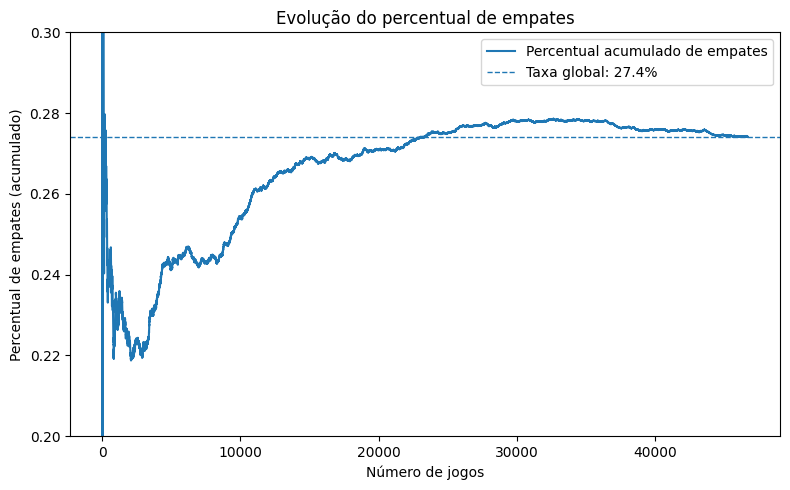

In [6]:
import matplotlib.pyplot as plt
is_draw = (df['home_score'] == df['away_score'])

# Percentual acumulado de empates a cada jogo (1º, 2º, ..., N)
cum_pct_draws = is_draw.cumsum() / np.arange(1, len(is_draw) + 1)

plt.figure(figsize=(8,5))
plt.plot(cum_pct_draws.index, cum_pct_draws.values, label='Percentual acumulado de empates')
# taxa global (linha de referência)
overall = is_draw.mean()
plt.axhline(overall, linestyle='--', linewidth=1, label=f'Taxa global: {overall:.1%}')
plt.xlabel('Número de jogos')
plt.ylim(0.2, 0.3)  # <<< fixando escala do eixo Y
plt.ylabel('Percentual de empates (acumulado)')
plt.title('Evolução do percentual de empates')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# pip install cmdstanpy pandas numpy scikit-learn
# Em Python (uma vez): 
#   from cmdstanpy import install_cmdstan
#   install_cmdstan()
import os
os.environ['PATH'] = r"C:\cmdstan\cmdstan-2.xx.y\stan\lib\stan_math\lib\tbb" + os.pathsep + os.environ.get('PATH','')

import numpy as np
import pandas as pd
import cmdstanpy
cmdstanpy.set_cmdstan_path("/home/enzou/cmdstan")

from sklearn.metrics import log_loss

# -------- Preparação do DataFrame --------
def prepare_df(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()
    if not np.issubdtype(df['date'].dtype, np.datetime64):
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.rename(columns={'home_player':'home','away_player':'away'})
    # outcome: 1=H, 2=D, 3=A
    def _y(r):
        if r['home_score'] > r['away_score']: return 1
        if r['home_score'] < r['away_score']: return 3
        return 2
    df['y'] = df.apply(_y, axis=1).astype(int)
    return df.sort_values('date').reset_index(drop=True)

def encode_teams(df):
    teams = pd.Index(sorted(pd.unique(df[['home','away']].values.ravel())))
    tid = {t:i+1 for i,t in enumerate(teams)}
    return teams, tid

def time_index(dts, freq='W'):
    # índice temporal (semanal por padrão). Mude para 'D' se quiser diário.
    per = pd.Series(dts).dt.to_period(freq).astype(str)
    uniq = pd.Index(sorted(per.unique()))
    mid = {p:i+1 for i,p in enumerate(uniq)}
    return per.map(mid).astype(int), len(uniq)

def build_stan_data(df, train_frac=1/3, s=400.0, freq='W'):
    df = df.sort_values('date').reset_index(drop=True)
    teams, tid = encode_teams(df)
    home = df['home'].map(tid).astype(int).values
    away = df['away'].map(tid).astype(int).values
    y = df['y'].astype(int).values
    t_idx, K = time_index(df['date'], freq=freq)
    t_idx = t_idx.values

    n = len(df)
    n_train = max(1, int(np.floor(train_frac * n)))
    split_date = df.loc[n_train-1, 'date']
    w = (df['date'].values <= split_date).astype(float)

    stan_data = {
        'N': n, 'T': len(teams), 'K': int(K),
        'home': home, 'away': away, 'y': y, 't_idx': t_idx,
        'w': w, 's': float(s)
    }
    meta = {
        'teams': teams,
        'split_date': pd.to_datetime(split_date),
        'mask_train': w==1.0,
        'mask_test': w==0.0,
        'time_index': t_idx,
        'freq': freq
    }
    return stan_data, meta

# -------- MCMC --------
def fit_mcmc(stan_file, stan_data, chains=4, draws=1000, warmup=1000, seed=42):
    model = CmdStanModel(stan_file=stan_file)
    fit = model.sample(
        data=stan_data,
        chains=chains, parallel_chains=chains,
        iter_sampling=draws, iter_warmup=warmup,
        adapt_delta=0.9, seed=seed
    )
    return model, fit

# -------- Avaliação --------
def posterior_mean_probs(fit):
    # pred_probs: [S, N, 3]
    probs = fit.stan_variable('pred_probs')
    return probs.mean(axis=0)  # [N,3]

def evaluate_split(df, prob_mean, meta):
    idx_test = np.where(meta['mask_test'])[0]
    y_true = df.iloc[idx_test]['y'].map({1:0,2:1,3:2}).values  # 0=H,1=D,2=A
    P = prob_mean[idx_test]
    ll = log_loss(y_true, P, labels=[0,1,2])
    acc = (P.argmax(axis=1) == y_true).mean()
    return {'n_test': int(len(idx_test)), 'logloss': float(ll), 'accuracy': float(acc)}

# -------- Extras: séries temporais de nu_t --------
def posterior_nu_series(fit, meta):
    # Recupera nu_t (transformed param) por draw e faz médias/quantis
    nu = fit.stan_variable('nu_t')    # shape: [S, K]
    nu_mean = nu.mean(axis=0)
    q025 = np.quantile(nu, 0.025, axis=0)
    q975 = np.quantile(nu, 0.975, axis=0)
    df_nu = pd.DataFrame({
        't_idx': np.arange(1, nu_mean.shape[0]+1),
        'nu_mean': nu_mean, 'nu_q025': q025, 'nu_q975': q975
    })
    df_nu['freq'] = meta['freq']
    return df_nu

# ------------- Uso -------------
df_in = df  # seu DataFrame original com as colunas pedidas
df = prepare_df(df_in)
stan_data, meta = build_stan_data(df, train_frac=1/3, s=400.0, freq='W')
model, fit = fit_mcmc('elo.stan', stan_data, chains=4, draws=1000, warmup=1000)
probs_mean = posterior_mean_probs(fit)
summary = evaluate_split(df, probs_mean, meta)
print("Corte de treino em:", meta['split_date'].date())
print("Teste:", summary)
df_nu = posterior_nu_series(fit, meta)   # série temporal da propensão a empates
print(df_nu.head())


ValueError: No CmdStan directory, path /home/enzou/cmdstan does not exist.

In [ ]:
import cmdstanpy
cmdstanpy.install_cmdstan(overwrite=True, progress=True)


CmdStan install directory: C:\Users\Enzo\.cmdstan
Installing CmdStan version: 2.36.0


0.00B [00:00, ?B/s]

Download successful, file: C:\Users\Enzo\AppData\Local\Temp\tmpgvvsxab7
Extracting distribution


  0%|          | 0/22079 [00:00<?, ?it/s]

Unpacked download as cmdstan-2.36.0
Building version cmdstan-2.36.0, may take several minutes, depending on your system.


 (00:00) |            | Building CmdStan                     

21:14:16 - cmdstanpy - WARNING - CmdStan installation failed.
'utf-8' codec can't decode byte 0x80 in position 7: invalid start byte


False